setting up

In [ ]:
!pip -q install dune-client

from google.colab import userdata
from dune_client.client import DuneClient

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 kB 6.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.


## Mint/Burn

In [ ]:
DUNE_API_KEY = userdata.get("DUNE_API_KEY")

dune = DuneClient(DUNE_API_KEY)
flow_resp = dune.get_latest_result(6744179)
flow_resp

ResultsResponse(execution_id='01KJBEE7E6QZ675YJMKDZB6N0S', query_id=6744179, state=<ExecutionState.COMPLETED: 'QUERY_STATE_COMPLETED'>, times=TimeData(submitted_at=datetime.datetime(2026, 2, 25, 22, 24, 14, 792108, tzinfo=tzlocal()), execution_started_at=datetime.datetime(2026, 2, 25, 22, 24, 19, 116708, tzinfo=tzlocal()), execution_ended_at=datetime.datetime(2026, 2, 25, 22, 24, 25, 75834, tzinfo=tzlocal()), expires_at=datetime.datetime(2026, 5, 26, 22, 24, 25, 75841, tzinfo=tzlocal()), cancelled_at=None), result=ExecutionResult(rows=[{'burn_usdy': 0, 'day': '2023-09-18 00:00:00.000 UTC', 'mint_usdy': 20091.96280658079, 'net_mint_usdy': 20091.96280658079, 'total_supply_usdy': 20091.96280658079}, {'burn_usdy': 0, 'day': '2023-09-25 00:00:00.000 UTC', 'mint_usdy': 102415.87543416626, 'net_mint_usdy': 102415.87543416626, 'total_supply_usdy': 122507.83824074705}, {'burn_usdy': 5011.891780325829, 'day': '2023-10-02 00:00:00.000 UTC', 'mint_usdy': 26867.888899416263, 'net_mint_usdy': 21855.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

flow_rows = flow_resp.result.rows
df_flow = pd.DataFrame(flow_rows)

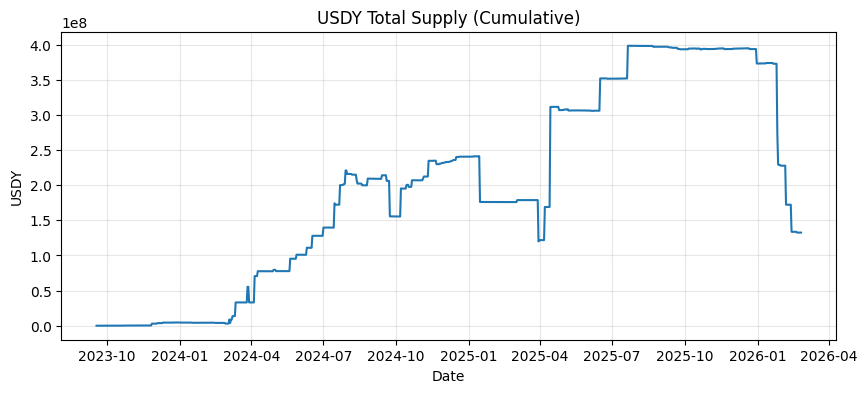

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# clean & sort
df_flow["day"] = pd.to_datetime(df_flow["day"])
for c in ["mint_usdy", "burn_usdy", "net_mint_usdy", "total_supply_usdy"]:
    df_flow[c] = pd.to_numeric(df_flow[c], errors="coerce")

df_flow = df_flow.sort_values("day").reset_index(drop=True)

# fill missing days so the chart looks continuous
all_days = pd.date_range(df_flow["day"].min(), df_flow["day"].max(), freq="D")
df_full = (
    df_flow.set_index("day")
          .reindex(all_days)
          .rename_axis("day")
          .reset_index()
)

# fill flows with 0 on missing days; carry forward total supply (or recompute from net flows)
for c in ["mint_usdy", "burn_usdy", "net_mint_usdy"]:
    df_full[c] = df_full[c].fillna(0.0)

# recompute cumulative supply from net flows to avoid NaNs after reindex
df_full["total_supply_usdy"] = df_full["net_mint_usdy"].cumsum()

# 1) Supply growth curve
plt.figure(figsize=(10,4))
plt.plot(df_full["day"], df_full["total_supply_usdy"])
plt.title("USDY Total Supply (Cumulative)")
plt.xlabel("Date")
plt.ylabel("USDY")
plt.grid(True, alpha=0.3)
plt.show()


Mint/Burn window: 2023-11-08 00:00:00+00:00 -> 2026-02-01 00:00:00+00:00


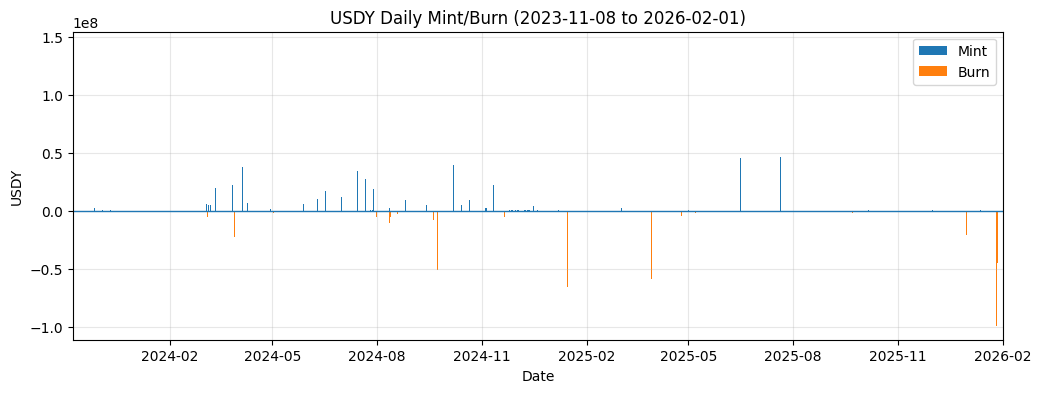

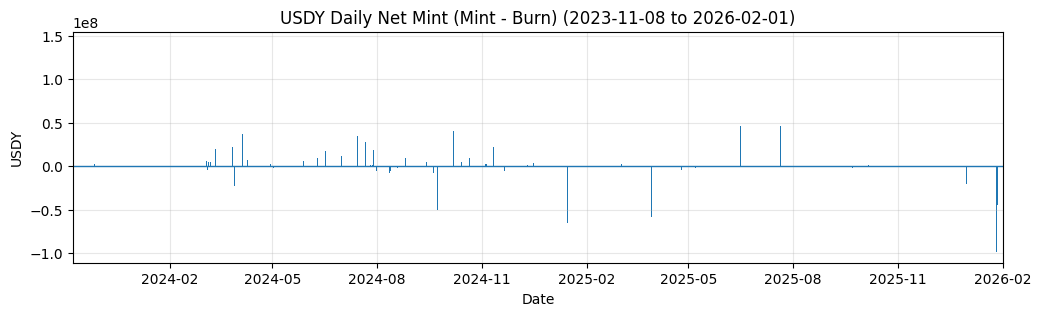

In [ ]:
# USDY Daily Mint/Burn + Net Mint (clean axis: START->END)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# set window
START = pd.Timestamp("2023-11-08", tz="UTC")
END   = pd.Timestamp("2026-02-01", tz="UTC")

# make sure df_full exists and has required columns
# expected cols: day, mint_usdy, burn_usdy, net_mint_usdy
df_full = df_full.copy()
df_full["day"] = pd.to_datetime(df_full["day"], utc=True, errors="coerce").dt.floor("D")
df_full = df_full.dropna(subset=["day"]).copy()

for c in ["mint_usdy", "burn_usdy", "net_mint_usdy"]:
    df_full[c] = pd.to_numeric(df_full[c], errors="coerce").fillna(0.0)

# filter to window
df_flow_win = df_full[(df_full["day"] >= START) & (df_full["day"] <= END)].copy()
df_flow_win = df_flow_win.sort_values("day").reset_index(drop=True)

print("Mint/Burn window:", df_flow_win["day"].min(), "->", df_flow_win["day"].max())

# x-axis formatting
locator = mdates.MonthLocator(interval=3)     # tick every 3 months
fmt = mdates.DateFormatter("%Y-%m")

# Plot 1: Daily Mint/Burn
plt.figure(figsize=(12,4))
plt.bar(df_flow_win["day"], df_flow_win["mint_usdy"], label="Mint")
plt.bar(df_flow_win["day"], -df_flow_win["burn_usdy"], label="Burn")
plt.axhline(0, linewidth=1)
plt.title(f"USDY Daily Mint/Burn ({START.date()} to {END.date()})")
plt.xlabel("Date"); plt.ylabel("USDY")
plt.legend()
plt.grid(True, alpha=0.3)

ax = plt.gca()
ax.set_xlim(START, END)
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(fmt)

plt.show()

# Plot 2: Daily Net Mint
plt.figure(figsize=(12,3))
plt.bar(df_flow_win["day"], df_flow_win["net_mint_usdy"])
plt.axhline(0, linewidth=1)
plt.title(f"USDY Daily Net Mint (Mint - Burn) ({START.date()} to {END.date()})")
plt.xlabel("Date"); plt.ylabel("USDY")
plt.grid(True, alpha=0.3)

ax = plt.gca()
ax.set_xlim(START, END)
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(fmt)

plt.show()

Top mint days identify adoption shocks (large inflows), while top burn days identify redemption shocks (large outflows), which are the relevant tail events for liquidity/peg stress analysis.

High holder concentration + lumpy burn days implies redemption risk is dominated by actions of a small number of large addresses rather than broad retail behavior.


In [ ]:
import pandas as pd

# set window (keep consistent)
START = pd.Timestamp("2023-11-08", tz="UTC")
END   = pd.Timestamp("2026-02-01", tz="UTC")

df_full = df_full.copy()
df_full["day"] = pd.to_datetime(df_full["day"], utc=True, errors="coerce").dt.floor("D")
df_full = df_full.dropna(subset=["day"]).copy()

for c in ["mint_usdy", "burn_usdy", "net_mint_usdy", "total_supply_usdy"]:
    if c in df_full.columns:
        df_full[c] = pd.to_numeric(df_full[c], errors="coerce")

# filter to window
df_flow_win = df_full[(df_full["day"] >= START) & (df_full["day"] <= END)].copy()
df_flow_win = df_flow_win.sort_values("day").reset_index(drop=True)

# Top 10 mint days (largest mint_usdy)
top10_mint = (
    df_flow_win.sort_values("mint_usdy", ascending=False)
    .head(10)[["day","mint_usdy","burn_usdy","net_mint_usdy","total_supply_usdy"]]
)

# Top 10 burn days (largest burn_usdy)
top10_burn = (
    df_flow_win.sort_values("burn_usdy", ascending=False)
    .head(10)[["day","burn_usdy","mint_usdy","net_mint_usdy","total_supply_usdy"]]
)

print(f"Top 10 Mint Days ({START.date()} to {END.date()}):")
display(top10_mint)

print(f"Top 10 Burn Days ({START.date()} to {END.date()}):")
display(top10_burn)

Top 10 Mint Days (2023-11-08 to 2026-02-01):


,day,mint_usdy,burn_usdy,net_mint_usdy,total_supply_usdy
523,2025-04-14 00:00:00+00:00,1.423408e+08,0.00000,1.423408e+08,3.113962e+08
516,2025-04-07 00:00:00+00:00,4.708533e+07,0.00000,4.708533e+07,1.689289e+08
621,2025-07-21 00:00:00+00:00,4.641818e+07,0.00000,4.641818e+07,3.983690e+08
586,2025-06-16 00:00:00+00:00,4.591232e+07,0.21400,4.591232e+07,3.519393e+08
334,2024-10-07 00:00:00+00:00,3.999496e+07,33457.72176,3.996150e+07,1.953413e+08
149,2024-04-05 00:00:00+00:00,3.749635e+07,0.00000,3.749635e+07,7.065468e+07
250,2024-07-15 00:00:00+00:00,3.453181e+07,0.00000,3.453181e+07,1.742019e+08
257,2024-07-22 00:00:00+00:00,2.779805e+07,0.00000,2.779805e+07,2.000933e+08
369,2024-11-11 00:00:00+00:00,2.236687e+07,0.00000,2.236687e+07,2.346938e+08
140,2024-03-27 00:00:00+00:00,2.226463e+07,0.00000,2.226463e+07,5.542296e+07


Top 10 Burn Days (2023-11-08 to 2026-02-01):


,day,burn_usdy,mint_usdy,net_mint_usdy,total_supply_usdy
810,2026-01-26 00:00:00+00:00,9.880249e+07,1.164631e+04,-9.879085e+07,2.739995e+08
434,2025-01-15 00:00:00+00:00,6.510807e+07,0.000000e+00,-6.510807e+07,1.761133e+08
508,2025-03-30 00:00:00+00:00,5.882159e+07,0.000000e+00,-5.882159e+07,1.199638e+08
320,2024-09-23 00:00:00+00:00,5.040183e+07,0.000000e+00,-5.040183e+07,1.556382e+08
811,2026-01-27 00:00:00+00:00,4.459432e+07,4.927195e+03,-4.458939e+07,2.294101e+08
142,2024-03-29 00:00:00+00:00,2.226463e+07,0.000000e+00,-2.226463e+07,3.315833e+07
784,2025-12-31 00:00:00+00:00,2.057048e+07,2.675511e+02,-2.057021e+07,3.731171e+08
278,2024-08-12 00:00:00+00:00,1.000000e+07,2.398460e+06,-7.601540e+06,2.073722e+08
316,2024-09-19 00:00:00+00:00,8.008450e+06,0.000000e+00,-8.008450e+06,2.060701e+08
379,2024-11-21 00:00:00+00:00,5.000061e+06,5.000000e+01,-5.000011e+06,2.298902e+08


	•	Flows are highly episodic: most days are near-zero, but a handful of days drive large supply changes.
	•	Mint spikes are large and clustered (several 20–140M USDY days), consistent with batch institutional subscriptions rather than steady retail inflows.
	•	Burn spikes are also concentrated, with the largest burn day (~98.8M) and several other large burn days, indicating lumpy redemption shocks that can dominate short-term liquidity needs.

In [ ]:
## Top N days
import pandas as pd
import numpy as np

def topN_days_share(df, col, N):
    total = df[col].sum()
    topN = df.sort_values(col, ascending=False).head(N)[col].sum()
    return float(topN), float(total), (topN / total * 100.0) if total > 0 else np.nan

rows = []
for col, label in [("mint_usdy", "Mint"), ("burn_usdy", "Burn")]:
    for N in [1, 5, 10, 20]:
        topN, total, share = topN_days_share(df_flow_win, col, N)
        rows.append({
            "flow_type": label,
            "TopN_days": N,
            "topN_volume": topN,
            "total_volume":v e total,
            "topN_share_pct": share
        })

df_lumpy = pd.DataFrame(rows)
df_lumpy

,flow_type,TopN_days,topN_volume,total_volume,topN_share_pct
0,Mint,1,1.423408e+08,6.614424e+08,21.519754
1,Mint,5,3.217516e+08,6.614424e+08,48.643928
2,Mint,10,4.662093e+08,6.614424e+08,70.483730
3,Mint,20,5.926825e+08,6.614424e+08,89.604557
4,Burn,1,9.880249e+07,4.341230e+08,22.759101
5,Burn,5,3.177283e+08,4.341230e+08,73.188543
6,Burn,10,3.835719e+08,4.341230e+08,88.355584
7,Burn,20,4.157716e+08,4.341230e+08,95.772764


	•	Mint concentration: Top 1 day = 21.5% of all mint; Top 10 days = 70.5%; Top 20 days = 89.6% → issuance is dominated by a small number of large days.
	•	Burn concentration is even more extreme: Top 5 burn days already explain 73.2% of total burn; Top 10 = 88.4%; Top 20 = 95.8% → redemption risk is tail-event driven, so stress/monitoring should focus on those extreme days rather than averages.

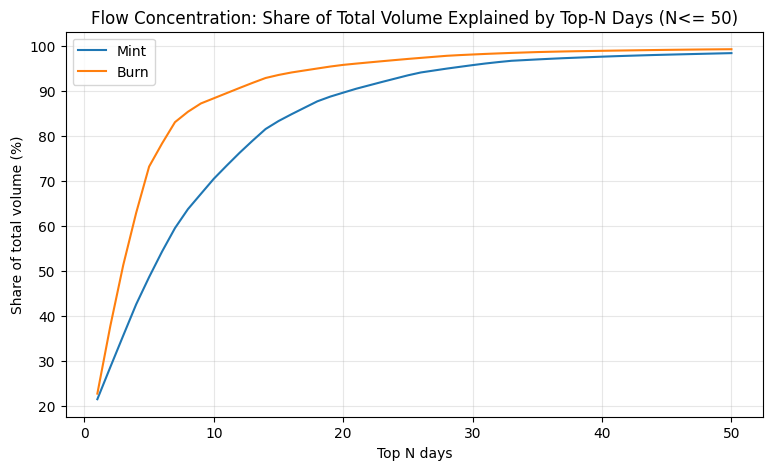

In [ ]:
## Top-N days share curve
import numpy as np
import matplotlib.pyplot as plt

def topN_share_curve(df, col, Nmax=50):
    x = np.arange(1, Nmax+1)
    s = df.sort_values(col, ascending=False)[col].values
    total = s.sum()
    # if fewer than Nmax days
    if len(s) < Nmax:
        s = np.pad(s, (0, Nmax-len(s)), constant_values=0.0)
    cum = np.cumsum(s[:Nmax])
    y = (cum / total * 100.0) if total > 0 else np.full(Nmax, np.nan)
    return x, y

Nmax = 50
x, y_mint = topN_share_curve(df_flow_win, "mint_usdy", Nmax=Nmax)
_, y_burn = topN_share_curve(df_flow_win, "burn_usdy", Nmax=Nmax)

plt.figure(figsize=(9,5))
plt.plot(x, y_mint, label="Mint")
plt.plot(x, y_burn, label="Burn")
plt.title(f"Flow Concentration: Share of Total Volume Explained by Top-N Days (N<= {Nmax})")
plt.xlabel("Top N days")
plt.ylabel("Share of total volume (%)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

	•	Both curves rise fast, meaning issuance and redemptions are dominated by a small number of extreme days (highly “lumpy” flows).
	•	The burn curve sits above mint (for the same Top-N), so redemptions are more concentrated than issuance: fewer days account for a larger share of total burn volume.
	•	Why mint < burn? Mint volume is spread across more medium/large days (more frequent batch subscriptions), while burn is driven by rarer, larger liquidation/redemption events—so burn has a heavier tail and concentrates faster.

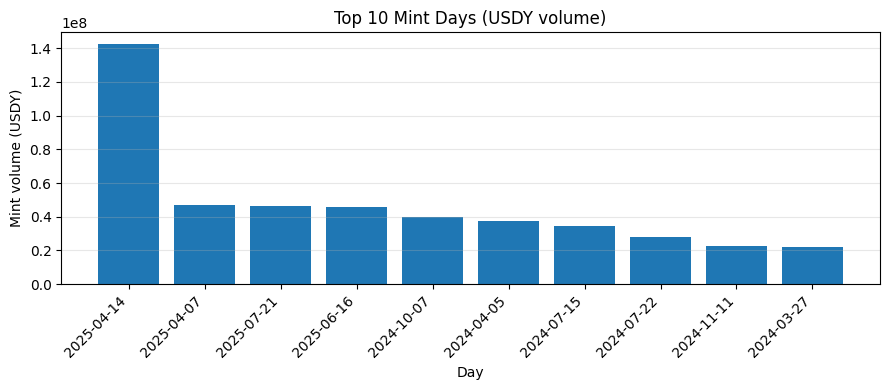

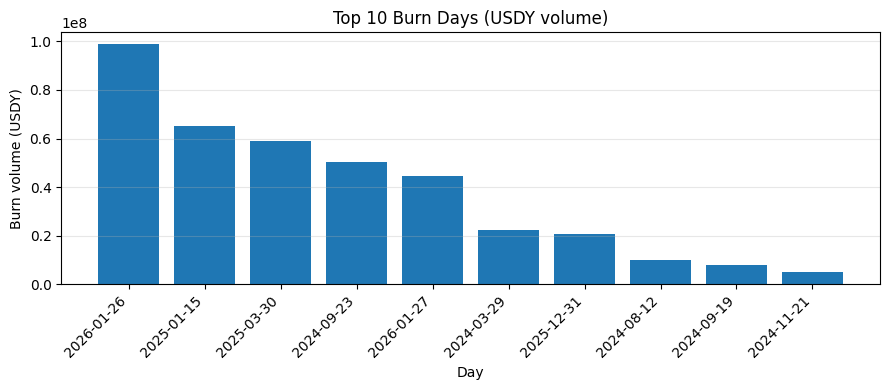

In [ ]:
## Top 10 mint&burn days
import matplotlib.pyplot as plt

top10_mint = df_flow_win.sort_values("mint_usdy", ascending=False).head(10)[["day","mint_usdy"]].copy()
top10_burn = df_flow_win.sort_values("burn_usdy", ascending=False).head(10)[["day","burn_usdy"]].copy()

# plot Top10 mint days
plt.figure(figsize=(9,4))
plt.bar(top10_mint["day"].dt.strftime("%Y-%m-%d"), top10_mint["mint_usdy"])
plt.xticks(rotation=45, ha="right")
plt.title("Top 10 Mint Days (USDY volume)")
plt.xlabel("Day")
plt.ylabel("Mint volume (USDY)")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# plot Top10 burn days
plt.figure(figsize=(9,4))
plt.bar(top10_burn["day"].dt.strftime("%Y-%m-%d"), top10_burn["burn_usdy"])
plt.xticks(rotation=45, ha="right")
plt.title("Top 10 Burn Days (USDY volume)")
plt.xlabel("Day")
plt.ylabel("Burn volume (USDY)")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

	•	Top 10 mint days: issuance is lumpy but more “tiered”—one very large mint day (~1.4e8) plus several mid-sized days (~2–5e7), suggesting batch institutional subscriptions spread across multiple events.
	•	Top 10 burn days: redemptions are even more tail-driven—one dominant burn day (~1.0e8) and a steep drop-off, implying liquidity/redemption risk is concentrated in a few extreme withdrawal events rather than steady outflows.

## Top-N Holders Concentration

In [ ]:
DUNE_API_KEY = userdata.get("DUNE_API_KEY")

dune = DuneClient(DUNE_API_KEY)
res = dune.get_latest_result(6735902)
res

ResultsResponse(execution_id='01KJBBBK548GZ0EHTTQJBWQBDE', query_id=6735902, state=<ExecutionState.COMPLETED: 'QUERY_STATE_COMPLETED'>, times=TimeData(submitted_at=datetime.datetime(2026, 2, 25, 21, 30, 22, 758098, tzinfo=tzlocal()), execution_started_at=datetime.datetime(2026, 2, 25, 21, 30, 47, 613080, tzinfo=tzlocal()), execution_ended_at=datetime.datetime(2026, 2, 25, 21, 32, 15, 25793, tzinfo=tzlocal()), expires_at=datetime.datetime(2026, 5, 26, 21, 32, 15, 25801, tzinfo=tzlocal()), cancelled_at=None), result=ExecutionResult(rows=[{'address': '0x6870289efc708e41a97ad5068a9f84b0dd2bfaed', 'balance_usdy': 22751500.173161894, 'pct_of_supply': 17.166052256519173}, {'address': '0xa5b614026dcb1ef6e0e39aa53351b4f4bd225302', 'balance_usdy': 18298255.997776728, 'pct_of_supply': 13.806070644586747}, {'address': '0xc9e397454f5478f4418e45181849c6ea66303d5a', 'balance_usdy': 17230923.91841801, 'pct_of_supply': 13.00076646201052}, {'address': '0xaf37c1167910ebc994e266949387d2c7c326b879', 'balan

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Robustly extract rows from dune-client response
if hasattr(res, "rows"):
    rows = res.rows
elif hasattr(res, "result") and hasattr(res.result, "rows"):
    rows = res.result.rows
elif isinstance(res, dict) and "result" in res and "rows" in res["result"]:
    rows = res["result"]["rows"]
else:
    raise ValueError("Cannot find rows in `res`. Print `res` and I will adapt the extractor.")

df = pd.DataFrame(rows)

# make sure numeric
df["balance_usdy"] = pd.to_numeric(df["balance_usdy"])
df["pct_of_supply"] = pd.to_numeric(df["pct_of_supply"])

df = df.sort_values("balance_usdy", ascending=False).reset_index(drop=True)
df.head()

,address,balance_usdy,pct_of_supply
0,0x6870289efc708e41a97ad5068a9f84b0dd2bfaed,2.275150e+07,17.166052
1,0xa5b614026dcb1ef6e0e39aa53351b4f4bd225302,1.829826e+07,13.806071
2,0xc9e397454f5478f4418e45181849c6ea66303d5a,1.723092e+07,13.000766
3,0xaf37c1167910ebc994e266949387d2c7c326b879,1.279587e+07,9.654513
4,0xc0db94fdde74f3902ea7995194d290f6bee78f8c,1.028082e+07,7.756897


In [ ]:
def topN_share(N):
    return float(df.head(N)["pct_of_supply"].sum())

for N in [1, 5, 10, 20, 50]:
    print(f"Top {N} share: {topN_share(N):.2f}%")

Top 1 share: 17.17%
Top 5 share: 61.38%
Top 10 share: 91.29%
Top 20 share: 99.10%
Top 50 share: 99.96%


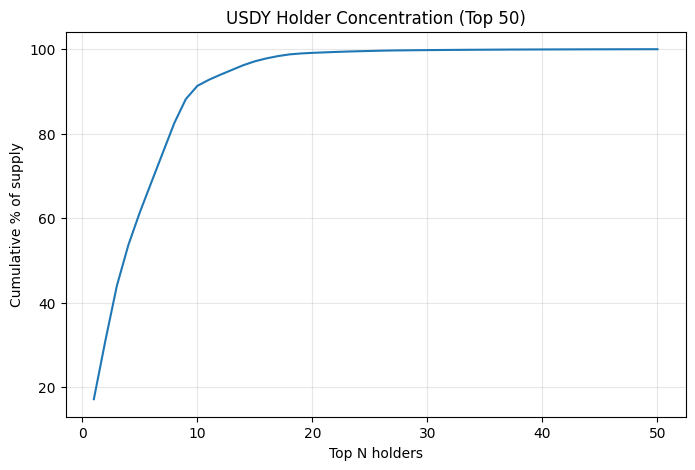

In [ ]:
df["rank"] = np.arange(1, len(df) + 1)
df["cum_pct"] = df["pct_of_supply"].cumsum()

plt.figure(figsize=(8,5))
plt.plot(df["rank"], df["cum_pct"])
plt.xlabel("Top N holders")
plt.ylabel("Cumulative % of supply")
plt.title("USDY Holder Concentration (Top 50)")
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
Ns = [1, 5, 10, 20, 50]
summary = pd.DataFrame({
    "TopN": Ns,
    "share_pct": [topN_share(N) for N in Ns]
})
summary

,TopN,share_pct
0,1,17.166052
1,5,61.384299
2,10,91.286731
3,20,99.098198
4,50,99.959354


	•	Extremely concentrated holder base: the curve rises very fast—Top 10 holders own ~91.29% of supply, and Top 5 already own ~61.38%, indicating control is dominated by a small set of large addresses.
	•	Tail risk implication: because supply is so concentrated, large mints/burns and redemption shocks are likely driven by a few entities, making liquidity risk “whale-driven” rather than broadly distributed across many small holders.

## Holder Distribution (Bucket)

In [ ]:
dune = DuneClient(DUNE_API_KEY)
res2 = dune.get_latest_result(6744084)
res2

ResultsResponse(execution_id='01KJBCCTZJVYBGNJ4V3AWQ39YK', query_id=6744084, state=<ExecutionState.COMPLETED: 'QUERY_STATE_COMPLETED'>, times=TimeData(submitted_at=datetime.datetime(2026, 2, 25, 21, 48, 32, 115399, tzinfo=tzlocal()), execution_started_at=datetime.datetime(2026, 2, 25, 21, 48, 33, 342465, tzinfo=tzlocal()), execution_ended_at=datetime.datetime(2026, 2, 25, 21, 48, 43, 216309, tzinfo=tzlocal()), expires_at=datetime.datetime(2026, 5, 26, 21, 48, 43, 216322, tzinfo=tzlocal()), cancelled_at=None), result=ExecutionResult(rows=[{'bucket': '<10', 'holders': 473, 'supply_in_bucket': 548.3816911995195}, {'bucket': '10-100', 'holders': 119, 'supply_in_bucket': 4070.7915855396814}, {'bucket': '100-1k', 'holders': 68, 'supply_in_bucket': 30872.71849708555}, {'bucket': '1k-10k', 'holders': 20, 'supply_in_bucket': 91538.63462949666}, {'bucket': '10k-100k', 'holders': 17, 'supply_in_bucket': 660345.5014902864}, {'bucket': '100k-1m', 'holders': 8, 'supply_in_bucket': 3051738.7211529124

In [ ]:
import pandas as pd

rows2 = res2.result.rows
df_bucket = pd.DataFrame(rows2)

order = ["<10","10-100","100-1k","1k-10k","10k-100k","100k-1m",">=1m"]
df_bucket["bucket"] = pd.Categorical(df_bucket["bucket"], categories=order, ordered=True)
df_bucket = df_bucket.sort_values("bucket").reset_index(drop=True)

df_bucket

,bucket,holders,supply_in_bucket
0,<10,473,5.483817e+02
1,10-100,119,4.070792e+03
2,100-1k,68,3.087272e+04
3,1k-10k,20,9.153863e+04
4,10k-100k,17,6.603455e+05
5,100k-1m,8,3.051739e+06
6,>=1m,15,1.286986e+08


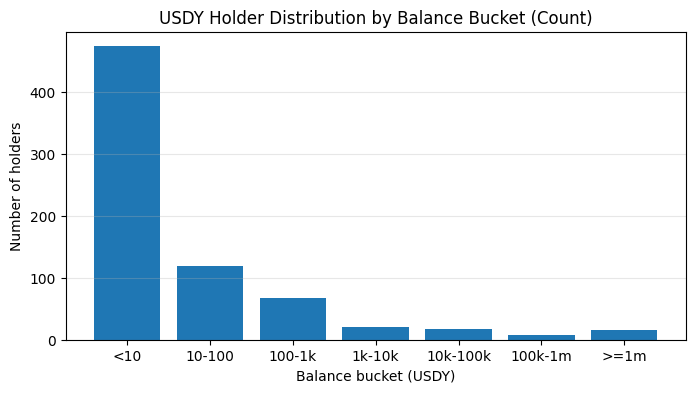

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.bar(df_bucket["bucket"], df_bucket["holders"])
plt.title("USDY Holder Distribution by Balance Bucket (Count)")
plt.xlabel("Balance bucket (USDY)")
plt.ylabel("Number of holders")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

The holder base is long-tailed in count, with most addresses holding small balances (<100 USDY).


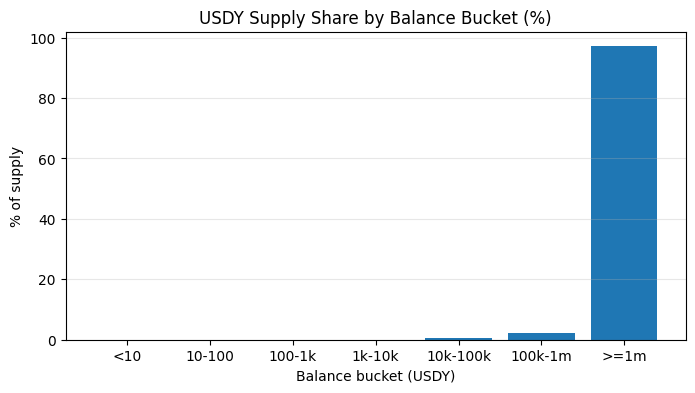

In [ ]:
df_bucket["pct_supply"] = df_bucket["supply_in_bucket"] / df_bucket["supply_in_bucket"].sum() * 100

import matplotlib.pyplot as plt
plt.figure(figsize=(8,4))
plt.bar(df_bucket["bucket"], df_bucket["pct_supply"])
plt.title("USDY Supply Share by Balance Bucket (%)")
plt.xlabel("Balance bucket (USDY)")
plt.ylabel("% of supply")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

Economically, supply is dominated by whales (>=1m USDY). This implies concentration risk and potential for large redemption shocks from a small set of addresses.


## HHI, Effective Number

In [ ]:
import numpy as np

# shares in decimals (e.g., 17% -> 0.17)
shares = df["pct_of_supply"].astype(float).values / 100.0

hhi_top50 = float(np.sum(shares**2))
eff_n_top50 = (1.0 / hhi_top50) if hhi_top50 > 0 else np.nan

print(f"HHI (Top50 only, lower bound): {hhi_top50:.4f}")
print(f"Effective # holders (Top50-only): {eff_n_top50:.2f}")

HHI (Top50 only, lower bound): 0.1006
Effective # holders (Top50-only): 9.94


 Top-50 holder shares imply HHI ≈ 0.1006 and an effective number of holders ≈ 9.94, meaning the supply behaves as if it were held by only ~10 equal-sized holders → high concentration / whale-driven risk.

## USDY Market Price Deviation vs $1
Because USDY is yield-bearing, persistent positive deviations can reflect accrued yield and/or redemption frictions rather than a depeg in the stablecoin sense.

In [ ]:
!rm -rf ONDO_analysis
!git clone https://github.com/lydialydia-lydia/ONDO_analysis.git
!ls -lah ONDO_analysis/data

Cloning into 'ONDO_analysis'...
remote: Enumerating objects: 15, done.
remote: Counting objects: 100% (15/15), done.
remote: Compressing objects: 100% (12/12), done.
remote: Total 15 (delta 3), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (15/15), 31.82 KiB | 1.87 MiB/s, done.
Resolving deltas: 100% (3/3), done.
total 80K
drwxr-xr-x 2 root root 4.0K Mar  1 21:05 .
drwxr-xr-x 5 root root 4.0K Mar  1 21:05 ..
-rw-r--r-- 1 root root    1 Mar  1 21:05 .gitkeep
-rw-r--r-- 1 root root  65K Mar  1 21:05 usdy-usd-max.csv


In [ ]:
import pandas as pd

START = pd.Timestamp("2023-11-08", tz="UTC")
END   = pd.Timestamp("2026-02-01", tz="UTC")  # inclusive

In [ ]:
import pandas as pd

PRICE_FILE = "ONDO_analysis/data/usdy-usd-max.csv"
df_px_raw = pd.read_csv(PRICE_FILE)

# parse time + price
df_px_raw["snapped_at"] = pd.to_datetime(df_px_raw["snapped_at"], utc=True, errors="coerce")
df_px_raw["price_usd"] = pd.to_numeric(df_px_raw["price"], errors="coerce")
df_px_raw = df_px_raw.dropna(subset=["snapped_at", "price_usd"]).copy()

# daily average
df_px_raw["day"] = df_px_raw["snapped_at"].dt.floor("D")
df_px = df_px_raw.groupby("day", as_index=False)["price_usd"].mean().sort_values("day")

# filter window (inclusive end)
df_px_win = df_px[(df_px["day"] >= START) & (df_px["day"] <= END)].copy()
df_px_win = df_px_win.sort_values("day").reset_index(drop=True)

print("Price window:", df_px_win["day"].min(), "->", df_px_win["day"].max())
df_px_win.head()

Price window: 2023-11-08 00:00:00+00:00 -> 2026-02-01 00:00:00+00:00


,day,price_usd
0,2023-11-08 00:00:00+00:00,1.012046
1,2023-11-09 00:00:00+00:00,1.012046
2,2023-11-10 00:00:00+00:00,1.022510
3,2023-11-11 00:00:00+00:00,1.017482
4,2023-11-12 00:00:00+00:00,1.015403


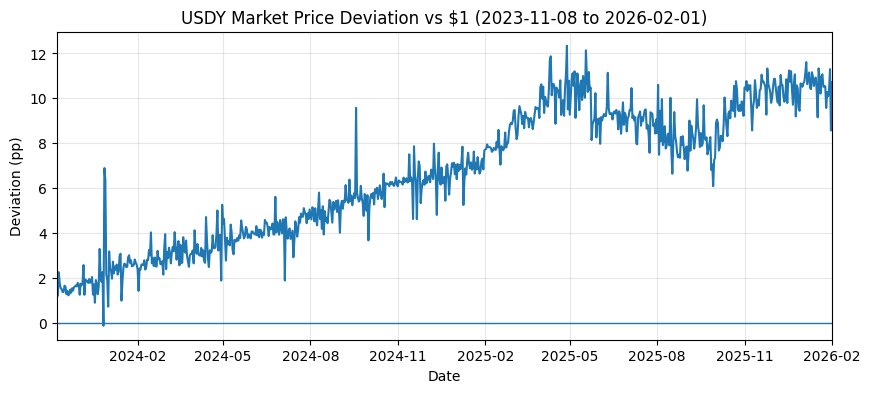

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

df_px_win["dev_pp"] = (df_px_win["price_usd"] - 1.0) * 100.0   # percentage points vs $1
df_px_win["abs_dev_pp"] = df_px_win["dev_pp"].abs()

locator = mdates.MonthLocator(interval=3)
fmt = mdates.DateFormatter("%Y-%m")

plt.figure(figsize=(10,4))
plt.plot(df_px_win["day"], df_px_win["dev_pp"])
plt.axhline(0, linewidth=1)
plt.title(f"USDY Market Price Deviation vs $1 ({START.date()} to {END.date()})")
plt.xlabel("Date")
plt.ylabel("Deviation (pp)")
plt.grid(True, alpha=0.3)

ax = plt.gca()
ax.set_xlim(START, END)
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(fmt)

plt.show()

USDY trades at a persistent premium above $1 (deviation mostly positive) and the premium trends upward over time, with short-lived spikes/dip. So this looks like yield/premium dynamics, not a tight stablecoin-style peg.

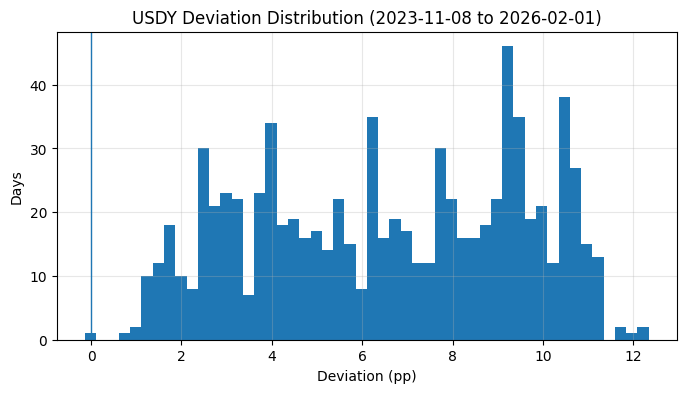

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.hist(df_px_win["dev_pp"].dropna(), bins=50)
plt.axvline(0, linewidth=1)
plt.title(f"USDY Deviation Distribution ({START.date()} to {END.date()})")
plt.xlabel("Deviation (pp)")
plt.ylabel("Days")
plt.grid(True, alpha=0.3)
plt.show()

 Deviations are rarely near 0 and cluster mostly around mid-to-high single digits up to ~10–12pp, confirming the premium is structural/persistent rather than occasional noise.

In [ ]:
import numpy as np

abs_dev = df_px_win["abs_dev_pp"].dropna()

print(f"Market price deviation summary ({START.date()} to {END.date()}, daily avg):")
print(f"Max |dev| (pp): {abs_dev.max():.3f}")
print(f"P95 |dev| (pp): {abs_dev.quantile(0.95):.3f}")
print(f"P99 |dev| (pp): {abs_dev.quantile(0.99):.3f}")

for band in [0.1, 0.5, 1.0]:
    print(f"Days with |dev| > {band:.1f}pp: {int((abs_dev > band).sum())} / {len(abs_dev)}")

Market price deviation summary (2023-11-08 to 2026-02-01, daily avg):
Max |dev| (pp): 12.344
P95 |dev| (pp): 10.766
P99 |dev| (pp): 11.236
Days with |dev| > 0.1pp: 817 / 817
Days with |dev| > 0.5pp: 816 / 817
Days with |dev| > 1.0pp: 813 / 817


	•	USDY trades above $1 on 816/817 days, with an average premium of ~6.58pp (≈ $1.066), so deviations vs $1 are structural rather than occasional.

  

In [ ]:
pos_days = int((df_px_win["dev_pp"] > 0).sum())
neg_days = int((df_px_win["dev_pp"] < 0).sum())
print(f"Days premium (dev>0): {pos_days} / {len(df_px_win)}")
print(f"Days discount (dev<0): {neg_days} / {len(df_px_win)}")
print(f"Mean deviation (pp): {df_px_win['dev_pp'].mean():.3f}")

Days premium (dev>0): 816 / 817
Days discount (dev<0): 1 / 817
Mean deviation (pp): 6.575



	•	The distribution is consistently high—P95 |dev| ≈ 10.77pp, P99 ≈ 11.24pp, max ≈ 12.34pp—indicating the market price rarely converges to $1 (more like a yield-bearing premium/discount process than a tight peg).

##Simulation

In [ ]:
# Cell 0) Assumptions & Goal

# This is NOT a price-forecast model.
# It is a "capacity planning" stress harness:
#   - Calibrate redemption shocks from historical burn data (p95/p99/max)
#   - Assume a daily redemption processing capacity (as % of outstanding supply)
#   - Simulate backlog clearance time under stress
# Required input: df_flow_win (your filtered windowed flows dataframe)
# Columns needed:
#   - day
#   - burn_usdy
#   - total_supply_usdy

In [ ]:
# Cell 1) Build burn% of supply (robust denominator) + diagnostics
import pandas as pd
import numpy as np

df_sim = df_flow_win.copy()

# Parse + clean
df_sim["day"] = pd.to_datetime(df_sim["day"], utc=True, errors="coerce").dt.floor("D")
df_sim["burn_usdy"] = pd.to_numeric(df_sim["burn_usdy"], errors="coerce").fillna(0.0)
df_sim["total_supply_usdy"] = pd.to_numeric(df_sim["total_supply_usdy"], errors="coerce")

df_sim = df_sim.dropna(subset=["day","total_supply_usdy"]).copy()
df_sim = df_sim[df_sim["total_supply_usdy"] > 0].sort_values("day").reset_index(drop=True)

# Use lagged supply as denominator (more stable than same-day supply)
df_sim["supply_lag1"] = df_sim["total_supply_usdy"].shift(1)
df_sim = df_sim.dropna(subset=["supply_lag1"]).copy()
df_sim = df_sim[df_sim["supply_lag1"] > 0].copy()

df_sim["burn_pct"] = df_sim["burn_usdy"] / df_sim["supply_lag1"] * 100.0

# Diagnostics: find any impossible / suspicious values
bad = df_sim[(df_sim["burn_pct"] < 0) | (df_sim["burn_pct"] > 100)].copy()
print("Window:", df_sim["day"].min(), "->", df_sim["day"].max())
print("Mean burn_pct (% of supply):", float(df_sim["burn_pct"].mean()))
print("Raw max burn_pct (%):", float(df_sim["burn_pct"].max()))
print("Num burn_pct outside [0,100]:", len(bad))

if len(bad) > 0:
    print("\nTop suspicious rows (burn_pct outside [0,100]):")
    display(bad.sort_values("burn_pct", ascending=False).head(10)[
        ["day","burn_usdy","supply_lag1","total_supply_usdy","burn_pct"]
    ])

# Apply physical constraint filter
df_sim_clean = df_sim[df_sim["burn_pct"].between(0, 100)].copy()
print("\nAfter filtering, max burn_pct (%):", float(df_sim_clean["burn_pct"].max()))

Window: 2023-11-09 00:00:00+00:00 -> 2026-02-01 00:00:00+00:00
Mean burn_pct (% of supply): 0.37438562593584407
Raw max burn_pct (%): 55.58715996865972
Num burn_pct outside [0,100]: 0

After filtering, max burn_pct (%): 55.58715996865972


In [ ]:
# Cell 2) Calibrate stress scenarios (p95/p99/max) from cleaned burn_pct
burn_pct = df_sim_clean["burn_pct"].values

scenarios = {
    "p95": float(np.quantile(burn_pct, 0.95)),
    "p99": float(np.quantile(burn_pct, 0.99)),
    "max": float(np.max(burn_pct)),
}

print("Stress scenarios (burn as % of lagged supply):")
for k, v in scenarios.items():
    print(f"  {k}: {v:.3f}%")

# Optional: show corresponding burn_usdy distribution
print("\nBurn_usdy scale (for reference):")
print("  p95 burn_usdy:", float(np.quantile(df_sim_clean["burn_usdy"].values, 0.95)))
print("  p99 burn_usdy:", float(np.quantile(df_sim_clean["burn_usdy"].values, 0.99)))
print("  max burn_usdy:", float(np.max(df_sim_clean["burn_usdy"].values)))

Stress scenarios (burn as % of lagged supply):
  p95: 0.121%
  p99: 6.738%
  max: 55.587%

Burn_usdy scale (for reference):
  p95 burn_usdy: 184762.8592890393
  p99 burn_usdy: 7557191.609693069
  max burn_usdy: 98802493.00831111


In [ ]:
# Cell 3) Define backlog clearance model (days_to_clear)
import numpy as np

def simulate_clear_time(shock_pct: float, capacity_pct_per_day: float) -> dict:
    """
    shock_pct: redemption shock as % of supply (one-day event)
    capacity_pct_per_day: processing capacity as % of supply per day

    Backlog model:
      backlog starts at shock_pct
      clears at capacity_pct_per_day per day
      time_to_clear = ceil(shock / capacity)
    """
    if capacity_pct_per_day <= 0:
        return {"shock_pct": shock_pct, "cap_pct_per_day": capacity_pct_per_day, "days_to_clear": np.inf}
    days = int(np.ceil(shock_pct / capacity_pct_per_day))
    return {"shock_pct": shock_pct, "cap_pct_per_day": capacity_pct_per_day, "days_to_clear": days}

# quick sanity check
simulate_clear_time(scenarios["p99"], 1.0)

{'shock_pct': 6.738057518449974, 'cap_pct_per_day': 1.0, 'days_to_clear': 7}

In [ ]:
# Cell 4) Run capacity grid -> results table

import pandas as pd

capacity_grid = [0.25, 0.5, 1.0, 2.0, 5.0]  # % of supply per day

rows = []
for cap in capacity_grid:
    for name, shock in scenarios.items():
        out = simulate_clear_time(shock_pct=shock, capacity_pct_per_day=cap)
        out["scenario"] = name
        rows.append(out)

df_capacity = pd.DataFrame(rows)[["scenario","shock_pct","cap_pct_per_day","days_to_clear"]]
df_capacity = df_capacity.sort_values(["cap_pct_per_day","scenario"]).reset_index(drop=True)
df_capacity

,scenario,shock_pct,cap_pct_per_day,days_to_clear
0,max,55.587160,0.25,223
1,p95,0.120733,0.25,1
2,p99,6.738058,0.25,27
3,max,55.587160,0.50,112
4,p95,0.120733,0.50,1
5,p99,6.738058,0.50,14
6,max,55.587160,1.00,56
7,p95,0.120733,1.00,1
8,p99,6.738058,1.00,7
9,max,55.587160,2.00,28


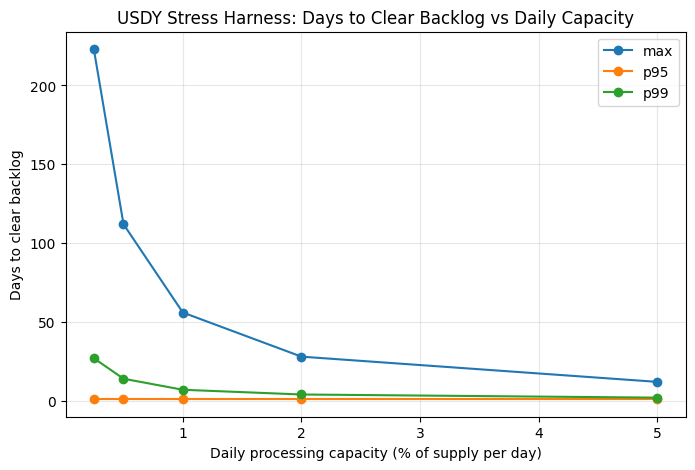

In [ ]:
# Cell 5) Plot: days_to_clear vs capacity
import matplotlib.pyplot as plt

pivot = df_capacity.pivot(index="cap_pct_per_day", columns="scenario", values="days_to_clear").sort_index()

plt.figure(figsize=(8,5))
for col in pivot.columns:
    plt.plot(pivot.index, pivot[col], marker="o", label=col)

plt.title("USDY Stress Harness: Days to Clear Backlog vs Daily Capacity")
plt.xlabel("Daily processing capacity (% of supply per day)")
plt.ylabel("Days to clear backlog")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

clearance time is highly nonlinear in capacity—p95 shocks clear in 1 day, p99 takes multiple days (e.g., 7 days at 1%/day), while the max outlier shock can take weeks to months unless capacity is very high.

This plot shows how quickly a redemption backlog would clear as daily processing capacity increases, under three historical shock sizes (p95, p99, and the max outlier). The p95 line stays near one day across all capacities, indicating typical large redemption days are easy to absorb operationally. In contrast, the p99 line drops sharply as capacity rises: at low capacity (0.25–0.5% of supply/day) the backlog can persist for weeks, while at 1%/day it clears in about a week and at 2%/day it clears in only a few days. The max outlier remains slow even at high capacity (still multi-week clearance), highlighting that extreme events cannot be handled by “normal” processing capacity alone and would require a separate contingency mode.

In [ ]:
# Cell 6) Monitoring thresholds table (flows-based)
import pandas as pd
import numpy as np

burn_p90 = float(np.quantile(burn_pct, 0.90))
burn_p95 = float(np.quantile(burn_pct, 0.95))
burn_p99 = float(np.quantile(burn_pct, 0.99))
burn_max = float(np.max(burn_pct))

df_alerts = pd.DataFrame([
    {"metric": "burn_pct_of_supply (lag1)", "threshold": f">{burn_p95:.3f}%", "severity": "High",
     "rationale": "Historical p95 redemption shock",
     "action": "Investigate redemption drivers; check operational/market liquidity"},
    {"metric": "burn_pct_of_supply (lag1)", "threshold": f">{burn_p99:.3f}%", "severity": "Severe",
     "rationale": "Historical p99 tail shock",
     "action": "Escalate; assess processing capacity; contingency response"},
    {"metric": "burn_pct_of_supply (lag1)", "threshold": f"≈{burn_max:.3f}%", "severity": "Extreme",
     "rationale": "Historical max shock (cleaned)",
     "action": "Full stress response; review playbook & capacity limits"},
])

df_alerts

,metric,threshold,severity,rationale,action
0,burn_pct_of_supply (lag1),>0.121%,High,Historical p95 redemption shock,Investigate redemption drivers; check operatio...
1,burn_pct_of_supply (lag1),>6.738%,Severe,Historical p99 tail shock,Escalate; assess processing capacity; continge...
2,burn_pct_of_supply (lag1),≈55.587%,Extreme,Historical max shock (cleaned),Full stress response; review playbook & capaci...


The actionable alert tiers—p95 as a “high” investigation trigger, p99 as a “severe” escalation trigger, and the historical max as an “extreme/crisis” scenario to activate the contingency playbook.

The stress harness translates historical burn tail events into an issuer-side capacity planning question: can redemptions be cleared within an acceptable time window, and what control parameters are required. Under typical conditions (p95), backlog clears in about one day even at low daily processing capacity, suggesting day-to-day redemptions are operationally manageable. In the tail (p99), clearance time becomes highly sensitive to capacity—roughly, a 1%-of-supply/day processing rate clears the p99 shock within about one week, while more stringent redemption timelines (3–4 days) would require closer to 2%/day. The max outlier scenario cannot be handled quickly by normal capacity alone (even high capacity still implies multi-week clearance), implying a separate crisis playbook is needed (temporary throttling/gates, batching, fee or window adjustments, and escalation procedures). Overall, the chart provides a data-driven bridge from observed lumpy, whale-driven redemption shocks to concrete operational controls: baseline capacity targets for p95/p99 and emergency controls for extreme events.

In [63]:
# Data-driven capacity recommendations from df_capacity
#   - df_capacity with columns: scenario, cap_pct_per_day, days_to_clear
#   - scenarios dict with scenarios["p99"] (optional, used for fallback)
# Goal:
#   - find the minimum capacity (cap_pct_per_day) that clears p99 within target_days

import numpy as np
import pandas as pd

def min_capacity_for_target(df_capacity: pd.DataFrame, scenario: str, target_days: int):
    df_s = df_capacity[df_capacity["scenario"] == scenario].copy()
    if df_s.empty:
        raise ValueError(f"No rows found for scenario='{scenario}' in df_capacity")

    # ensure numeric
    df_s["cap_pct_per_day"] = pd.to_numeric(df_s["cap_pct_per_day"])
    df_s["days_to_clear"] = pd.to_numeric(df_s["days_to_clear"])

    # capacities that meet target
    feasible = df_s[df_s["days_to_clear"] <= target_days].sort_values("cap_pct_per_day")
    if not feasible.empty:
        best = feasible.iloc[0]
        return float(best["cap_pct_per_day"]), int(best["days_to_clear"])

    # fallback: if grid doesn't contain enough capacity, compute required continuous capacity
    # requires the shock size for that scenario
    shock_row = df_s.iloc[0]
    shock_pct = float(shock_row["shock_pct"]) if "shock_pct" in df_s.columns else None
    if shock_pct is None and "scenarios" in globals() and scenario in scenarios:
        shock_pct = float(scenarios[scenario])

    if shock_pct is None:
        return None, None

    required = shock_pct / target_days
    return float(required), None

targets = [7, 3]
scenario_name = "p99"

print(f"Capacity recommendations for scenario={scenario_name}:")
for t in targets:
    cap, achieved_days = min_capacity_for_target(df_capacity, scenario_name, t)
    if achieved_days is not None:
        print(f"- To clear {scenario_name} within ≤{t} days: need capacity ≥ {cap:.3f}% supply/day "
              f"(grid achieves {achieved_days} days at {cap:.3f}%)")
    else:
        print(f"- To clear {scenario_name} within ≤{t} days: grid insufficient; "
              f"continuous minimum capacity ≈ {cap:.3f}% supply/day")

Capacity recommendations for scenario=p99:
- To clear p99 within ≤7 days: need capacity ≥ 1.000% supply/day (grid achieves 7 days at 1.000%)
- To clear p99 within ≤3 days: need capacity ≥ 5.000% supply/day (grid achieves 2 days at 5.000%)


Based on the stress harness results, a daily processing capacity of 1.0% of supply/day is sufficient to clear a p99 burn shock within 7 days, while meeting a tighter 3-day clearance goal would require substantially higher throughput; within the tested grid, the smallest capacity that achieves this is 5.0% of supply/day (which clears the p99 shock in 2 days).
